# Build and test your first machine learning model using python and scikit-learn

There are many users of online trading platforms and these companies would like to run analytics on and predict churn based on user activity on the platform. Since competition is rife, keeping customers happy so they do not move their investments elsewhere is key to maintaining profitability.

In this notebook, we'll use scikit-learn to predict classes. scikit-learn provides implementations of many classification algorithms. In here, we have chosen the random forest classification algorithm to walk through all the different steps.

To help visualize what we are doing, we'll use 2D and 3D charts to show how the classes look (with 3 selected dimensions) with matplotlib and scikitplot python libraries.

<a id="top"></a>
## Table of Contents

1. [安裝套件](#cell1)
2. [匯入函式庫](#cell2)
3. [載入資料](#cell3)
4. [資料探索 — 欄位型態與缺失值](#cell4)
5. [資料探索 — 目標變數分布](#cell5)
6. [資料前處理 — 移除不需要的欄位](#cell6)
7. [資料前處理 — 類別型特徵處理](#cell7)
8. [資料前處理 — 數值型特徵處理](#cell8)
9. [資料前處理 — 建立 ColumnTransformer Pipeline](#cell9)
10. [準備特徵與標籤](#cell10)
11. [資料視覺化 — 2D 與 3D 散佈圖](#cell11)
12. [切分訓練集與測試集](#cell12)
13. [定義輔助函式](#cell13)
14. [建立 Random Forest 模型與 Pipeline](#cell14)
15. [訓練模型](#cell15)
16. [模型預測](#cell16)
17. [模型評估 — 視覺化比較](#cell17)
18. [模型評估 — 混淆矩陣與分類報告](#cell18)
19. [模型評估 — 比較長條圖](#cell19)

<a id="cell1"></a>
## Cell 1: 安裝套件
[Top](#top)

安裝所需的 Python 套件。

**注意：** 部分安裝需要重新啟動 kernel 才能生效。

In [1]:
# # ====== Cell 1：安裝套件 ======
# # 本專案的目標是透過機器學習模型，根據客戶在線上交易平台的行為資料，
# # 預測客戶的流失風險（Churn Risk），分為 High、Medium、Low 三個等級。
# # 以下安裝本專案所需的所有 Python 套件。
#
# # 安裝 pandas：用於資料讀取、清洗與操作的核心套件
# !pip install pandas==0.24.2
# # 安裝 pandas_ml：提供機器學習相關的 pandas 擴充功能
# !pip install --user pandas_ml==0.6.1
# # 安裝 matplotlib：Python 最常用的繪圖套件，用於產生各種統計圖表
# # 此處指定版本以避免混淆矩陣圖表被截斷的已知問題
# !pip install matplotlib==3.1.0
# # 安裝 scikit-learn：Python 最主流的機器學習套件，提供分類、迴歸、分群等演算法
# !pip install --user scikit-learn==0.21.3
# # 安裝 scikit-plot：基於 matplotlib 的機器學習視覺化工具，可快速繪製混淆矩陣等評估圖表
# !pip install -q scikit-plot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 29.7 MB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "/Users/joseph/Library/Python/3.12/lib/python/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/Users/joseph/Library/Python/3.12/lib/python/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "/Users/joseph/Library/Python/3.12/lib/python/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 143, in get_requires_for_build_wheel
          ret

<a id="cell2"></a>
## Cell 2: 匯入函式庫
[Top](#top)

匯入 sklearn 預處理、模型訓練、評估工具，以及 pandas、numpy、matplotlib 等視覺化套件。

In [2]:
# ====== Cell 2：匯入函式庫 ======
# 匯入本專案所需的所有模組，涵蓋資料前處理、模型訓練、評估與視覺化。

# --- 資料前處理相關 ---
# LabelEncoder：將文字標籤（如 High/Medium/Low）轉換為數字（如 0/1/2），供模型使用
# OneHotEncoder：將類別型特徵轉換為獨熱編碼（binary vector），避免模型誤解類別間的大小關係
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# SimpleImputer：用於填補資料中的缺失值（例如用眾數填補遺漏的性別欄位）
from sklearn.impute import SimpleImputer
# MinMaxScaler：將數值特徵縮放到 [0, 1] 區間（本專案未實際使用，但已匯入備用）
from sklearn.preprocessing import MinMaxScaler
# StandardScaler：將數值特徵標準化為平均值=0、標準差=1，確保不同量級的特徵對模型的影響一致
from sklearn.preprocessing import StandardScaler
# ColumnTransformer：可針對不同欄位套用不同的前處理方式（例如類別欄位做編碼、數值欄位做標準化）
# make_column_transformer：ColumnTransformer 的簡便建構方式
from sklearn.compose import ColumnTransformer, make_column_transformer
# Pipeline：將多個前處理步驟與模型串接成一條流水線，確保訓練與預測時的處理步驟一致
from sklearn.pipeline import Pipeline

# --- 模型訓練與評估相關 ---
# train_test_split：將資料集切分為訓練集與測試集，避免模型在已見過的資料上評估（過擬合）
from sklearn.model_selection import train_test_split
# accuracy_score：計算模型的整體準確率（正確預測數 / 總預測數）
# classification_report：產生完整的分類報告，包含 precision、recall、F1-score
from sklearn.metrics import accuracy_score, classification_report

# --- 資料處理 ---
# pandas：表格式資料處理的核心套件，用於讀取 CSV、篩選欄位、分組統計等
# numpy：數值運算套件，提供陣列操作與數學函式
import pandas as pd, numpy as np

# --- 視覺化相關 ---
# matplotlib.pyplot：繪圖主模組，用於繪製散佈圖、長條圖等
import matplotlib.pyplot as plt
# Axes3D：支援 3D 散佈圖的繪製（在 matplotlib 中啟用 3D 投影）
from mpl_toolkits.mplot3d import Axes3D
# mcolors：matplotlib 的顏色工具模組
import matplotlib.colors as mcolors
# mpatches：用於建立圖例（legend）中的色塊標籤
import matplotlib.patches as mpatches
# scikitplot：快速繪製機器學習評估圖表（如混淆矩陣），省去手動排版的麻煩
import scikitplot as skplt

<a id="cell3"></a>
## Cell 3: 載入資料
[Top](#top)

從 GitHub 讀取客戶交易資料 CSV 檔案，並檢視前幾筆資料。

In [3]:
# ====== Cell 3：載入資料 ======
# 從 GitHub 上的 IBM 開放資料集讀取客戶交易資料。
# 這份資料包含客戶的個人屬性（性別、年齡、婚姻狀態等）與交易行為（交易金額、頻率等），
# 以及目標欄位 CHURNRISK（流失風險等級），是我們要預測的標籤。
# 注意：此資料集的 GENDER 欄位刻意包含缺失值，用於練習缺失值處理。

# 使用 pandas 的 read_csv 從網址直接讀取 CSV 檔案，存入 DataFrame
df_churn_pd = pd.read_csv(
    "https://raw.githubusercontent.com/IBM/ml-learning-path-assets/master/data/mergedcustomers_missing_values_GENDER.csv")
# 顯示前 5 筆資料，快速確認資料是否正確載入、欄位名稱與內容是否合理
df_churn_pd.head()

,ID,CHURNRISK,GENDER,STATUS,CHILDREN,ESTINCOME,HOMEOWNER,AGE,TOTALDOLLARVALUETRADED,TOTALUNITSTRADED,LARGESTSINGLETRANSACTION,SMALLESTSINGLETRANSACTION,PERCENTCHANGECALCULATION,DAYSSINCELASTLOGIN,DAYSSINCELASTTRADE,NETREALIZEDGAINS_YTD,NETREALIZEDLOSSES_YTD
0,1703,Medium,NaN,M,2,28766.9,N,47,6110.61,58,1527.6525,152.76525,8.70,2,13,0.0000,152.76525
1,1704,Low,NaN,M,2,91272.2,Y,25,26992.70,13,13496.3500,1349.63500,3.25,4,10,1349.6350,0.00000
2,1705,Low,NaN,S,0,73228.3,N,42,22472.25,28,11236.1250,1123.61250,7.00,4,5,1123.6125,0.00000
3,1706,High,M,M,1,64792.3,N,52,13051.31,36,6525.6550,652.56550,9.00,3,6,0.0000,652.56550
4,1707,High,F,S,0,93322.1,Y,40,29922.99,8,14961.4950,1496.14950,2.00,4,9,0.0000,1496.14950


<a id="cell4"></a>
## Cell 4: 資料探索 — 欄位型態與缺失值
[Top](#top)

檢視每個欄位的資料型態與非空值數量。注意 Gender 欄位有 3 筆缺失值，後續會在前處理步驟中處理。

In [4]:
# ====== Cell 4：資料探索 — 欄位型態與缺失值 ======
# 在建模前，必須先了解資料的基本結構，才能決定後續的前處理策略。

# 印出每個欄位的資料型態（int64、float64、object 等）
# 重點觀察：哪些是數值型（可直接用於模型）、哪些是類別型（需要編碼轉換）
print("The dataset contains columns of the following data types : \n" +str(df_churn_pd.dtypes))

# 印出每個欄位的非空值數量
# 重點觀察：若某欄位的數量少於總筆數（2066），表示該欄位有缺失值
# 例如 GENDER 只有 2063 筆，代表有 3 筆缺失，後續需要用 SimpleImputer 填補
print("\nThe dataset contains following number of records for each of the columns : \n" +str(df_churn_pd.count()))

The dataset contains columns of the following data types : 
ID                             int64
CHURNRISK                        str
GENDER                           str
STATUS                           str
CHILDREN                       int64
ESTINCOME                    float64
HOMEOWNER                        str
AGE                            int64
TOTALDOLLARVALUETRADED       float64
TOTALUNITSTRADED               int64
LARGESTSINGLETRANSACTION     float64
SMALLESTSINGLETRANSACTION    float64
PERCENTCHANGECALCULATION     float64
DAYSSINCELASTLOGIN             int64
DAYSSINCELASTTRADE             int64
NETREALIZEDGAINS_YTD         float64
NETREALIZEDLOSSES_YTD        float64
dtype: object

The dataset contains following number of records for each of the columns : 
ID                           2066
CHURNRISK                    2066
GENDER                       2063
STATUS                       2066
CHILDREN                     2066
ESTINCOME                    2066
HOMEOWNER       

<a id="cell5"></a>
## Cell 5: 資料探索 — 目標變數分布
[Top](#top)

觀察 CHURNRISK（流失風險）的 High / Medium / Low 三個類別的樣本數量分布。

Each category within the churnrisk column has the following count : 
CHURNRISK
High      983
Low       699
Medium    384
dtype: int64


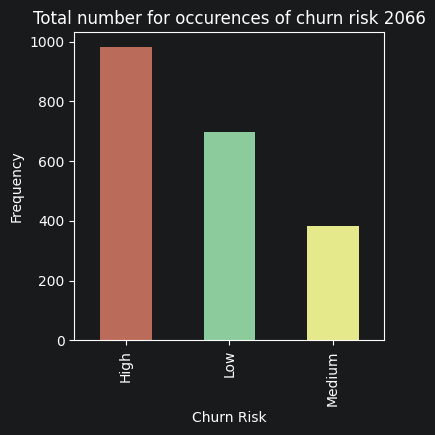

In [5]:
# ====== Cell 5：資料探索 — 目標變數分布 ======
# 檢視目標變數 CHURNRISK 的類別分布，這是建模前的關鍵步驟。
# 若類別嚴重不平衡（例如 99% Low、1% High），模型可能會偏向多數類別，
# 導致少數類別的預測效果很差。了解分布後才能決定是否需要做資料平衡處理。

# 印出 CHURNRISK 各類別的筆數統計
print( "Each category within the churnrisk column has the following count : ")
print(df_churn_pd.groupby(['CHURNRISK']).size())

# 繪製長條圖，直覺呈現 High / Medium / Low 三類的樣本數量
# 顏色對應：紅棕色=#BB6B5A（High）、綠色=#8CCB9B（Medium）、黃色=#E5E88B（Low）
index = ['High','Medium','Low']
churn_plot = df_churn_pd['CHURNRISK'].value_counts(sort=True, ascending=False).plot(kind='bar',
            figsize=(4,4),title="Total number for occurences of churn risk "
            + str(df_churn_pd['CHURNRISK'].count()), color=['#BB6B5A','#8CCB9B','#E5E88B'])
# 設定 X 軸標籤為「流失風險等級」
churn_plot.set_xlabel("Churn Risk")
# 設定 Y 軸標籤為「出現次數」；末尾加分號抑制 Jupyter 自動印出回傳值
churn_plot.set_ylabel("Frequency");

<a id="cell6"></a>
## Cell 6: 資料前處理 — 移除不需要的欄位
[Top](#top)

移除 ID 欄位，因為它不具預測意義。

In [6]:
# ====== Cell 6：資料前處理 — 移除不需要的欄位 ======
# ID 欄位只是每位客戶的唯一識別碼，不包含任何與流失風險相關的資訊。
# 若保留，模型可能會把 ID 當成有意義的特徵來學習，反而降低預測能力。

# 移除 ID 欄位，axis=1 表示刪除的是「欄」（column），而非「列」（row）
df_churn_pd = df_churn_pd.drop(['ID'], axis=1)

# 確認 ID 已被移除，檢視前 5 筆資料
df_churn_pd.head()

,CHURNRISK,GENDER,STATUS,CHILDREN,ESTINCOME,HOMEOWNER,AGE,TOTALDOLLARVALUETRADED,TOTALUNITSTRADED,LARGESTSINGLETRANSACTION,SMALLESTSINGLETRANSACTION,PERCENTCHANGECALCULATION,DAYSSINCELASTLOGIN,DAYSSINCELASTTRADE,NETREALIZEDGAINS_YTD,NETREALIZEDLOSSES_YTD
0,Medium,NaN,M,2,28766.9,N,47,6110.61,58,1527.6525,152.76525,8.70,2,13,0.0000,152.76525
1,Low,NaN,M,2,91272.2,Y,25,26992.70,13,13496.3500,1349.63500,3.25,4,10,1349.6350,0.00000
2,Low,NaN,S,0,73228.3,N,42,22472.25,28,11236.1250,1123.61250,7.00,4,5,1123.6125,0.00000
3,High,M,M,1,64792.3,N,52,13051.31,36,6525.6550,652.56550,9.00,3,6,0.0000,652.56550
4,High,F,S,0,93322.1,Y,40,29922.99,8,14961.4950,1496.14950,2.00,4,9,0.0000,1496.14950


<a id="cell7"></a>
## Cell 7: 資料前處理 — 類別型特徵處理
[Top](#top)

定義類別型欄位（GENDER、STATUS、HOMEOWNER），使用 SimpleImputer 以眾數填補缺失值，再用 OneHotEncoder 進行獨熱編碼。

In [7]:
# ====== Cell 7：資料前處理 — 類別型特徵處理 ======
# 機器學習模型只能處理數值資料，無法直接理解「Male」、「Female」這類文字。
# 因此需要將類別型欄位轉換為數值表示。

# 定義需要做類別編碼的欄位：性別、婚姻狀態、是否為屋主
categoricalColumns = ['GENDER', 'STATUS', 'HOMEOWNER']

print("Categorical columns : " )
print(categoricalColumns)

# 建立缺失值填補器：以「出現最頻繁的值」（眾數）來填補缺失值
# 例如 GENDER 有 3 筆缺失，若大多數客戶為 Male，就用 Male 填補
impute_categorical = SimpleImputer(strategy="most_frequent")

# 建立獨熱編碼器：將每個類別轉為一組 0/1 的二元欄位
# 例如 GENDER 有 M、F 兩種值，會展開為 GENDER_M 和 GENDER_F 兩個欄位
# handle_unknown='ignore' 表示遇到訓練時沒見過的類別值時，不會報錯而是全部設為 0
onehot_categorical = OneHotEncoder(handle_unknown='ignore')

# 將填補缺失值與獨熱編碼串成一條 Pipeline
# 執行順序：先填補缺失值 → 再做獨熱編碼，確保流程一致且不會遺漏步驟
categorical_transformer = Pipeline(steps=[('impute',impute_categorical),('onehot',onehot_categorical)])

Categorical columns : 
['GENDER', 'STATUS', 'HOMEOWNER']


<a id="cell8"></a>
## Cell 8: 資料前處理 — 數值型特徵處理
[Top](#top)

自動偵測數值型欄位，使用 StandardScaler 進行標準化（零均值、單位變異數）。

In [8]:
# ====== Cell 8：資料前處理 — 數值型特徵處理 ======
# 不同數值欄位的量級差異很大（例如收入可能是數萬元，交易天數可能是個位數）。
# 若不做標準化，量級大的特徵會主導模型的學習，量級小的特徵容易被忽略。

# 自動偵測所有資料型態為浮點數（float）或整數（int）的欄位
# 這些就是我們的數值型特徵，不需要做類別編碼，但需要做數值標準化
numericalColumns = df_churn_pd.select_dtypes(include=[float, int]).columns

print("Numerical columns : " )
print(numericalColumns)

# 建立標準化器 StandardScaler：將每個數值欄位轉換為平均值=0、標準差=1 的分布
# 公式：z = (x - 平均值) / 標準差
scaler_numerical = StandardScaler()

# 將標準化步驟包裝成 Pipeline（雖然只有一步，但統一用 Pipeline 方便後續整合）
numerical_transformer = Pipeline(steps=[('scale',scaler_numerical)])

Numerical columns : 
Index(['CHILDREN', 'ESTINCOME', 'AGE', 'TOTALDOLLARVALUETRADED',
       'TOTALUNITSTRADED', 'LARGESTSINGLETRANSACTION',
       'SMALLESTSINGLETRANSACTION', 'PERCENTCHANGECALCULATION',
       'DAYSSINCELASTLOGIN', 'DAYSSINCELASTTRADE', 'NETREALIZEDGAINS_YTD',
       'NETREALIZEDLOSSES_YTD'],
      dtype='str')


<a id="cell9"></a>
## Cell 9: 資料前處理 — 建立 ColumnTransformer Pipeline
[Top](#top)

將類別型與數值型的前處理步驟組合成 ColumnTransformer，並展示轉換後的資料樣貌。

In [9]:
# ====== Cell 9：資料前處理 — 建立 ColumnTransformer Pipeline ======
# ColumnTransformer 是整個前處理的核心：它能同時對不同欄位套用不同的轉換方式，
# 將類別型欄位的編碼與數值型欄位的標準化整合在一個步驟中完成。

# 版本一：僅處理類別欄位（用於中間檢視），其餘欄位原封不動傳過去（passthrough）
preprocessorForCategoricalColumns = ColumnTransformer(transformers=[('cat', categorical_transformer,
                                                                     categoricalColumns)],
                                            remainder="passthrough")
# 版本二：同時處理類別欄位（編碼）與數值欄位（標準化），這才是最終模型使用的版本
preprocessorForAllColumns = ColumnTransformer(transformers=[('cat', categorical_transformer, categoricalColumns),
                                                            ('num',numerical_transformer,numericalColumns)],
                                            remainder="passthrough")

# 以下是暫時性的轉換展示，讓我們能觀察前處理後資料長什麼樣子
# 實際建模時，轉換會在 Pipeline 內自動執行，不需要手動呼叫

# 展示：僅對類別欄位做轉換後的結果（獨熱編碼後變成多個 0/1 欄位）
df_churn_pd_temp = preprocessorForCategoricalColumns.fit_transform(df_churn_pd)
print("Data after transforming :")
print(df_churn_pd_temp)

# 展示：對所有欄位做完整轉換後的結果（類別編碼 + 數值標準化）
df_churn_pd_temp_2 = preprocessorForAllColumns.fit_transform(df_churn_pd)
print("Data after transforming :")
print(df_churn_pd_temp_2)

Data after transforming :
[[1.0 0.0 0.0 ... 13 0.0 152.76525]
 [1.0 0.0 0.0 ... 10 1349.635 0.0]
 [1.0 0.0 0.0 ... 5 1123.6125 0.0]
 ...
 [1.0 0.0 0.0 ... 11 0.0 82.50825]
 [1.0 0.0 0.0 ... 5 930.093 0.0]
 [0.0 1.0 0.0 ... 8 1041.604 0.0]]
Data after transforming :
[[1.0 0.0 0.0 ... -0.6792731303453047 -0.5106065181930338 'Medium']
 [1.0 0.0 0.0 ... 1.8354629319820521 -0.7959345330293706 'Low']
 [1.0 0.0 0.0 ... 1.4143217110983428 -0.7959345330293706 'Low']
 ...
 [1.0 0.0 0.0 ... -0.6792731303453047 -0.6418293606808149 'Medium']
 [1.0 0.0 0.0 ... 1.053742394902809 -0.7959345330293706 'Low']
 [0.0 1.0 0.0 ... 1.261517632686496 -0.7959345330293706 'Low']]


<a id="cell10"></a>
## Cell 10: 準備特徵與標籤
[Top](#top)

將 CHURNRISK 從 DataFrame 中分離作為標籤（y），其餘欄位作為特徵（X）。使用 LabelEncoder 將文字標籤編碼為數字。

In [10]:
# ====== Cell 10：準備特徵與標籤 ======
# 監督式學習需要明確區分「輸入特徵 X」與「輸出標籤 y」。
# X 是模型用來學習的依據（客戶的各種屬性與行為），
# y 是模型要預測的目標（流失風險等級）。

# 從 DataFrame 中移除 CHURNRISK 欄位，剩下的所有欄位作為輸入特徵 X
features = []
features = df_churn_pd.drop(['CHURNRISK'], axis=1)

# 將 CHURNRISK 欄位單獨取出作為標籤（僅供參考，後續用 label 變數）
label_churn = pd.DataFrame(df_churn_pd, columns = ['CHURNRISK'])
# 建立 LabelEncoder：負責將文字標籤轉為數字，以及之後將數字還原為文字
label_encoder = LabelEncoder()
# 取出 CHURNRISK 欄位的原始文字值
label = df_churn_pd['CHURNRISK']

# 將文字標籤編碼為數字：High→0、Low→1、Medium→2（按字母順序排列）
# fit_transform 會先學習所有類別（fit），再將其轉換為數字（transform）
label = label_encoder.fit_transform(label)
# 印出編碼結果，確認轉換是否正確
print("Encoded value of Churnrisk after applying label encoder : " + str(label))

Encoded value of Churnrisk after applying label encoder : [2 1 1 ... 2 1 1]


<a id="cell11"></a>
## Cell 11: 資料視覺化 — 2D 與 3D 散佈圖
[Top](#top)

以 ESTINCOME、DAYSSINCELASTTRADE、TOTALDOLLARVALUETRADED 三個維度，觀察不同流失風險類別在特徵空間中的分布。

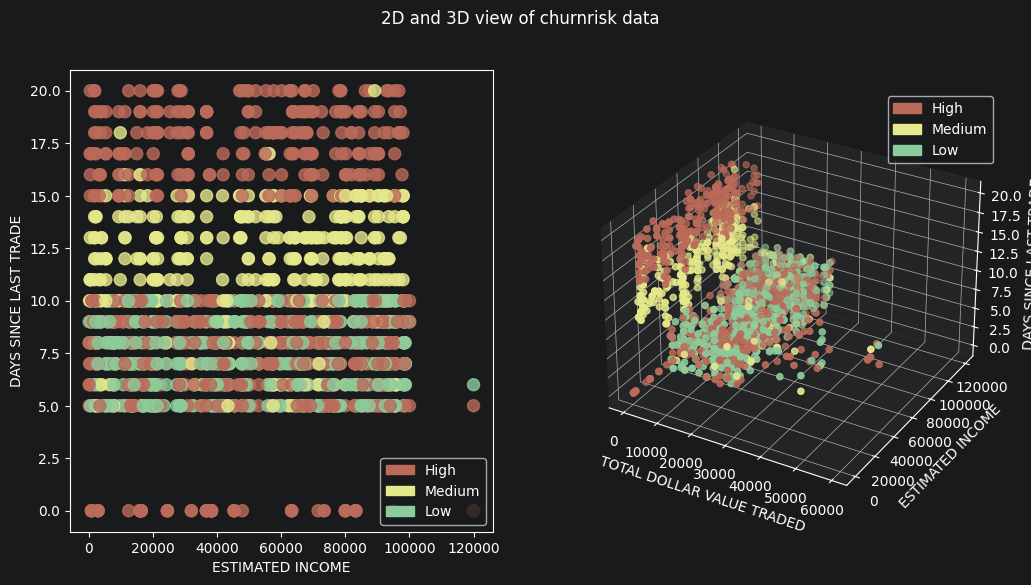

In [11]:
# ====== Cell 11：資料視覺化 — 2D 與 3D 散佈圖 ======
# 在訓練模型之前，先用圖表觀察資料的分布情況。
# 若不同類別在特徵空間中有明顯的分群，代表模型有機會學到有效的分類規則。
# 若完全混在一起，則預測難度較高。

# 設定散佈圖中每個點的大小
area = 75
# 取出三個關鍵特徵作為視覺化的維度
x = df_churn_pd['ESTINCOME']              # X 軸：客戶的預估收入
y = df_churn_pd['DAYSSINCELASTTRADE']      # Y 軸：距離上次交易的天數（越久越可能流失）
z = df_churn_pd['TOTALDOLLARVALUETRADED']  # Z 軸（3D 用）：交易總金額

# 建立圖例色塊：讓讀者知道每種顏色代表哪個風險等級
pop_a = mpatches.Patch(color='#BB6B5A', label='High')    # 紅棕色 = 高風險
pop_b = mpatches.Patch(color='#E5E88B', label='Medium')  # 黃色 = 中風險
pop_c = mpatches.Patch(color='#8CCB9B', label='Low')     # 綠色 = 低風險

# 定義顏色對應函式：將編碼後的數字標籤轉為對應的顏色
def colormap(risk_list):
    cols=[]
    for l in risk_list:
        if l==0:                        # 0 = High（高風險）
            cols.append('#BB6B5A')      # 紅棕色
        elif l==2:                      # 2 = Medium（中風險）
            cols.append('#E5E88B')      # 黃色
        elif l==1:                      # 1 = Low（低風險）
            cols.append('#8CCB9B')      # 綠色
    return cols

# 建立一個包含兩個子圖的畫布（左：2D、右：3D）
fig = plt.figure(figsize=(12,6))
fig.suptitle('2D and 3D view of churnrisk data')

# --- 左圖：2D 散佈圖（收入 vs 距上次交易天數）---
ax = fig.add_subplot(1, 2,1)
# 每個點代表一位客戶，顏色對應其流失風險等級
ax.scatter(x, y, alpha=0.8, c=colormap(label), s= area)
ax.set_ylabel('DAYS SINCE LAST TRADE')
ax.set_xlabel('ESTIMATED INCOME')
plt.legend(handles=[pop_a,pop_b,pop_c])

# --- 右圖：3D 散佈圖（交易總額 × 收入 × 距上次交易天數）---
# 多一個維度可以看到 2D 看不到的分群結構
ax = fig.add_subplot(1,2,2, projection='3d')
ax.scatter(z, x, y, c=colormap(label), marker='o')
ax.set_xlabel('TOTAL DOLLAR VALUE TRADED')
ax.set_ylabel('ESTIMATED INCOME')
ax.set_zlabel('DAYS SINCE LAST TRADE')
plt.legend(handles=[pop_a,pop_b,pop_c])

# 顯示圖表
plt.show()

<a id="cell12"></a>
## Cell 12: 切分訓練集與測試集
[Top](#top)

使用 `train_test_split` 將資料以 75/25 比例分為訓練集與測試集。設定 `random_state=0` 確保結果可重現。

In [12]:
# ====== Cell 12：切分訓練集與測試集 ======
# 機器學習的核心原則：不能用訓練過的資料來評估模型，否則會高估模型能力（過擬合）。
# 因此需要將資料分成兩份：訓練集用來學習規則，測試集用來驗證效果。

# train_test_split 預設以 75% / 25% 的比例切分資料
# random_state=0 確保每次執行都得到相同的切分結果（可重現性）
# X_train, y_train：訓練用的特徵與標籤
# X_test, y_test：測試用的特徵與標籤
X_train, X_test, y_train, y_test = train_test_split(features,label , random_state=0)

# 印出訓練集與測試集的維度，確認資料切分是否合理
print("Dimensions of datasets that will be used for training : Input features"+str(X_train.shape)+
      " Output label" + str(y_train.shape))
print("Dimensions of datasets that will be used for testing : Input features"+str(X_test.shape)+
      " Output label" + str(y_test.shape))

Dimensions of datasets that will be used for training : Input features(1549, 15) Output label(1549,)
Dimensions of datasets that will be used for testing : Input features(517, 15) Output label(517,)


<a id="cell13"></a>
## Cell 13: 定義輔助函式
[Top](#top)

定義後續模型評估所需的視覺化輔助函式：
- `colormap()`: 將風險等級對應到顏色
- `two_d_compare()`: 2D 散佈圖比較實際值與預測值
- `three_d_compare()`: 3D 散佈圖比較實際值與預測值
- `model_metrics()`: 混淆矩陣與分類報告

In [13]:
# ====== Cell 13：定義輔助函式 ======
# 以下函式用於模型評估階段的視覺化，將「實際值」與「預測值」以圖形方式比較，
# 幫助我們直觀判斷模型的分類效果。

# --- 顏色對應函式（與 Cell 11 相同邏輯，此處重新定義以供後續函式使用）---
def colormap(risk_list):
    cols=[]
    for l in risk_list:
        if l==0:                        # 0 = High
            cols.append('#BB6B5A')
        elif l==2:                      # 2 = Medium
            cols.append('#E5E88B')
        elif l==1:                      # 1 = Low
            cols.append('#8CCB9B')
    return cols

# --- 2D 比較函式：並排呈現實際值與預測值的散佈圖 ---
# 若兩張圖的顏色分布越接近，代表模型預測越準確
def two_d_compare(y_test,y_pred,model_name):
    area = (12 * np.random.rand(40))**2
    # 建立 1×2 的子圖版面
    plt.subplots(ncols=2, figsize=(10,4))
    # 標題同時顯示模型名稱與準確率
    plt.suptitle('Actual vs Predicted data : ' +model_name + '. Accuracy : %.2f' % accuracy_score(y_test, y_pred))

    # 左圖：實際的流失風險分布
    plt.subplot(121)
    plt.scatter(X_test['ESTINCOME'], X_test['DAYSSINCELASTTRADE'], alpha=0.8, c=colormap(y_test))
    plt.title('Actual')
    plt.legend(handles=[pop_a,pop_b,pop_c])

    # 右圖：模型預測的流失風險分布
    plt.subplot(122)
    plt.scatter(X_test['ESTINCOME'], X_test['DAYSSINCELASTTRADE'],alpha=0.8, c=colormap(y_pred))
    plt.title('Predicted')
    plt.legend(handles=[pop_a,pop_b,pop_c])

    plt.show()

# 取出測試集的三個特徵，供 3D 圖使用
x = X_test['TOTALDOLLARVALUETRADED']  # 交易總金額
y = X_test['ESTINCOME']               # 預估收入
z = X_test['DAYSSINCELASTTRADE']       # 距上次交易天數

# 重新建立圖例色塊（因為變數作用域的關係，需要在此處重新定義）
pop_a = mpatches.Patch(color='#BB6B5A', label='High')
pop_b = mpatches.Patch(color='#E5E88B', label='Medium')
pop_c = mpatches.Patch(color='#8CCB9B', label='Low')

# --- 3D 比較函式：以 3D 散佈圖並排呈現實際值與預測值 ---
# 3D 圖能揭示 2D 無法觀察到的分群結構
def three_d_compare(y_test,y_pred,model_name):
    fig = plt.figure(figsize=(12,10))
    fig.suptitle('Actual vs Predicted (3D) data : ' +model_name + '. Accuracy : %.2f' % accuracy_score(y_test, y_pred))

    # 左圖：實際值的 3D 分布
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=colormap(y_test), marker='o')
    ax.set_xlabel('TOTAL DOLLAR VALUE TRADED')
    ax.set_ylabel('ESTIMATED INCOME')
    ax.set_zlabel('DAYS SINCE LAST TRADE')
    plt.legend(handles=[pop_a,pop_b,pop_c])
    plt.title('Actual')

    # 右圖：預測值的 3D 分布
    ax = fig.add_subplot(122, projection='3d')
    ax.scatter(x, y, z, c=colormap(y_pred), marker='o')
    ax.set_xlabel('TOTAL DOLLAR VALUE TRADED')
    ax.set_ylabel('ESTIMATED INCOME')
    ax.set_zlabel('DAYS SINCE LAST TRADE')
    plt.legend(handles=[pop_a,pop_b,pop_c])
    plt.title('Predicted')

    plt.show()


# --- 模型評估指標函式：混淆矩陣 + 分類報告 ---
def model_metrics(y_test,y_pred):
    # 印出預測結果中包含哪些類別，確認模型是否涵蓋所有風險等級
    print("Decoded values of Churnrisk after applying inverse of label encoder : " + str(np.unique(y_pred)))

    # 繪製混淆矩陣：顯示每個類別被正確/錯誤分類的數量
    # 對角線上的數字越大越好（代表正確分類），非對角線的數字代表錯誤分類
    skplt.metrics.plot_confusion_matrix(y_test,y_pred,text_fontsize="small",cmap='Greens',figsize=(6,4))
    plt.show()

    # 印出分類報告：包含每個類別的 precision（精確率）、recall（召回率）、F1-score
    # precision = 預測為該類別的資料中，有多少是真的該類別
    # recall = 實際為該類別的資料中，有多少被正確預測出來
    # F1-score = precision 與 recall 的調和平均數，綜合衡量模型效果
    print("The classification report for the model : \n\n"+ classification_report(y_test, y_pred))

<a id="cell14"></a>
## Cell 14: 建立 Random Forest 模型與 Pipeline
[Top](#top)

建立 `RandomForestClassifier`（100 棵樹、最大深度 2），並將前處理的 ColumnTransformer 與分類器組合成完整的 Pipeline。

In [14]:
# ====== Cell 14：建立 Random Forest 模型與 Pipeline ======
# Random Forest（隨機森林）是一種整合學習方法，由多棵決策樹投票決定最終分類結果。
# 優點：不容易過擬合、對缺失值與離群值有一定容忍力、不需要太多參數調整就能有不錯的效果。

# 匯入隨機森林分類器
from sklearn.ensemble import RandomForestClassifier

# 定義模型名稱（用於後續圖表標題顯示）
model_name = "Random Forest Classifier"

# 建立隨機森林分類器：
# n_estimators=100：建立 100 棵決策樹，透過多數決投票來提升預測穩定性
# max_depth=2：每棵樹最多只能有 2 層深度，限制模型複雜度以避免過擬合
# random_state=0：固定隨機種子，確保每次執行結果一致（可重現性）
randomForestClassifier = RandomForestClassifier(n_estimators=100, max_depth=2,random_state=0)

# 建立完整的機器學習 Pipeline：
# 步驟一（preprocessorAll）：對輸入資料做前處理（類別編碼 + 數值標準化）
# 步驟二（classifier）：將前處理後的資料餵入隨機森林分類器
# Pipeline 的好處是確保訓練與預測時使用完全相同的前處理流程，避免資料洩漏（data leakage）
rfc_model = Pipeline(steps=[('preprocessorAll',preprocessorForAllColumns),('classifier', randomForestClassifier)])

<a id="cell15"></a>
## Cell 15: 訓練模型
[Top](#top)

使用訓練集擬合 Random Forest 模型。

In [15]:
# ====== Cell 15：訓練模型 ======
# 將訓練集資料餵入 Pipeline，模型會自動完成：
# 1. 前處理：填補缺失值 → 類別編碼 → 數值標準化
# 2. 訓練：隨機森林從處理後的資料中學習「哪些特徵組合對應哪種流失風險」
# 訓練完成後，模型內部已儲存學到的分類規則，可用於預測新資料。

# fit() 是機器學習中「訓練」的標準方法名稱
# X_train：訓練集的輸入特徵（客戶屬性與行為）
# y_train：訓練集的正確標籤（流失風險等級）
rfc_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessorAll', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

<a id="cell16"></a>
## Cell 16: 模型預測
[Top](#top)

對測試集進行預測，產生預測結果。

In [16]:
# ====== Cell 16：模型預測 ======
# 用訓練好的模型對「從未見過的」測試集資料進行預測。
# 模型會根據訓練時學到的規則，為每位測試集客戶預測其流失風險等級。
# 這個預測結果將與實際標籤（y_test）比較，以評估模型的泛化能力。

# predict() 會自動對 X_test 做前處理（與訓練時相同），再產生預測結果
# y_pred_rfc 是一個數字陣列，0=High、1=Low、2=Medium
y_pred_rfc = rfc_model.predict(X_test)

<a id="cell17"></a>
## Cell 17: 模型評估 — 視覺化比較
[Top](#top)

使用 2D 散佈圖直觀比較測試集的實際值（Actual）與預測值（Predicted）的差異。

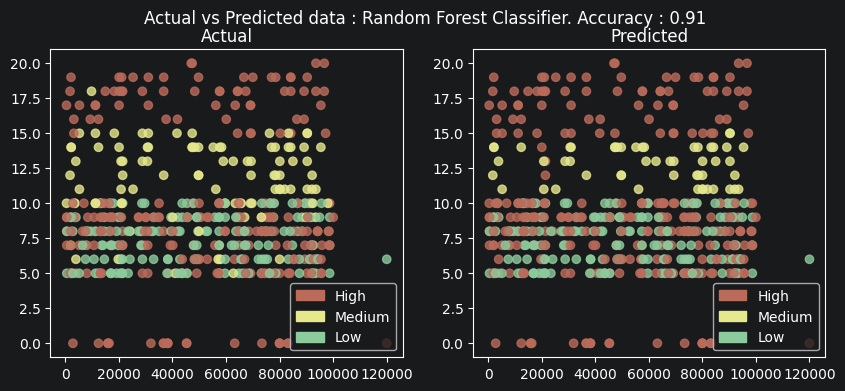

In [17]:
# ====== Cell 17：模型評估 — 視覺化比較 ======
# 使用 2D 散佈圖並排比較「實際的流失風險」與「模型預測的流失風險」。
# 若兩張圖的顏色分布高度相似，代表模型的分類效果良好。
# 若有大面積顏色差異，表示模型在某些特徵區間的預測不準確。

# 呼叫 Cell 13 定義的 2D 比較函式，傳入實際值、預測值與模型名稱
two_d_compare(y_test,y_pred_rfc,model_name)

# 可選：取消下方註解以顯示 3D 比較圖
# three_d_compare(y_test,y_pred_rfc,model_name)

<a id="cell18"></a>
## Cell 18: 模型評估 — 混淆矩陣與分類報告
[Top](#top)

將編碼後的標籤還原為原始文字（High/Medium/Low），繪製混淆矩陣並輸出分類報告（precision、recall、F1-score）。

Decoded values of Churnrisk after applying inverse of label encoder : ['High' 'Low' 'Medium']


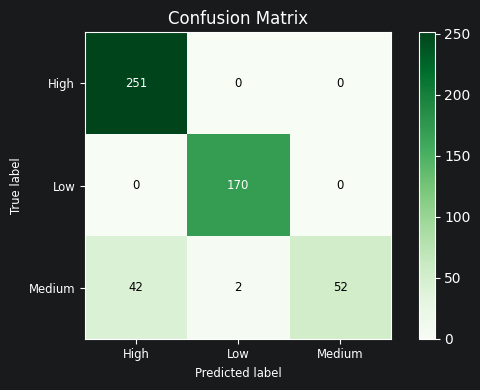

The classification report for the model : 

              precision    recall  f1-score   support

        High       0.86      1.00      0.92       251
         Low       0.99      1.00      0.99       170
      Medium       1.00      0.54      0.70        96

    accuracy                           0.91       517
   macro avg       0.95      0.85      0.87       517
weighted avg       0.93      0.91      0.91       517



In [18]:
 # ====== Cell 18：模型評估 — 混淆矩陣與分類報告 ======
# 混淆矩陣與分類報告是評估分類模型最重要的工具。
# 單看準確率可能會被不平衡的資料誤導，但混淆矩陣能清楚顯示每個類別的分類細節。

# 將數字標籤還原為原始文字（0→High、1→Low、2→Medium）
# 這樣混淆矩陣與報告中顯示的是易讀的文字標籤，而非數字
y_test = label_encoder.inverse_transform(y_test)
y_pred_rfc = label_encoder.inverse_transform(y_pred_rfc)

# 呼叫 Cell 13 定義的 model_metrics 函式，產生混淆矩陣與分類報告
model_metrics(y_test,y_pred_rfc)

<a id="cell19"></a>
## Cell 19: 模型評估 — 比較長條圖
[Top](#top)

以長條圖比較 Random Forest 預測結果與實際值的各類別頻率，觀察模型是否系統性地高估或低估某個類別。

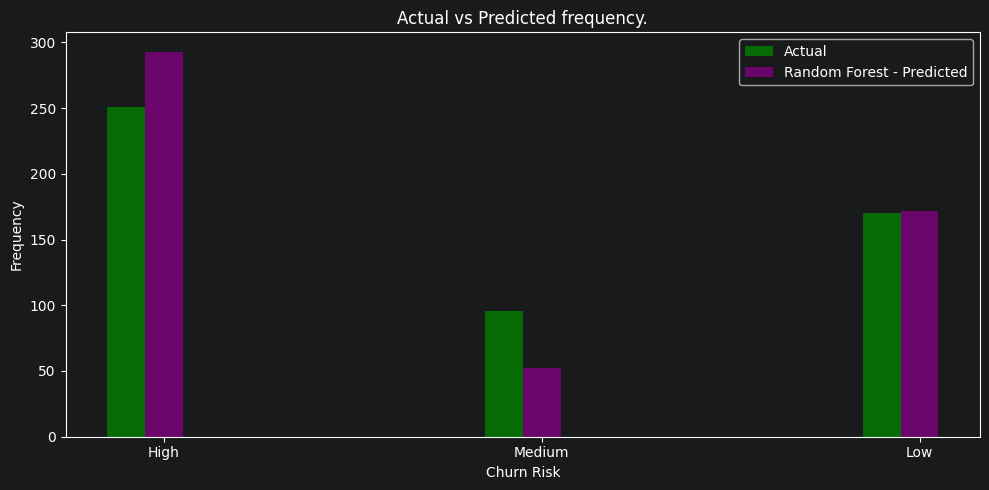

In [19]:
# ====== Cell 19：模型評估 — 比較長條圖 ======
# 用長條圖比較各類別在「實際資料」與「模型預測」中的出現頻率。
# 若模型的預測頻率與實際頻率接近，代表模型沒有系統性地偏向某個類別。
# 若某類別被大量高估或低估，需要進一步調查原因（可能是資料不平衡或模型參數需要調整）。

# 統計實際值中各類別的出現次數
uniqueValues, occurCount = np.unique(y_test, return_counts=True)
# 按照 High、Medium、Low 的順序排列頻率（注意索引順序因字母排序而不同）
frequency_actual = (occurCount[0],occurCount[2],occurCount[1])

# 統計預測值中各類別的出現次數
uniqueValues, occurCount = np.unique(y_pred_rfc, return_counts=True)
frequency_predicted_rfc = (occurCount[0],occurCount[2],occurCount[1])

# 設定長條圖參數
n_groups = 3  # 三個類別：High、Medium、Low
fig, ax = plt.subplots(figsize=(10,5))
index = np.arange(n_groups)  # X 軸的位置 [0, 1, 2]
bar_width = 0.1              # 每根長條的寬度
opacity = 0.8                # 長條的透明度

# 繪製實際值的長條（綠色）
rects1 = plt.bar(index, frequency_actual, bar_width,
alpha=opacity,
color='g',
label='Actual')

# 繪製預測值的長條（紫色），位置向右偏移一個 bar_width 以便並排顯示
rects6 = plt.bar(index + bar_width, frequency_predicted_rfc, bar_width,
alpha=opacity,
color='purple',
label='Random Forest - Predicted')

# 設定圖表標籤與標題
plt.xlabel('Churn Risk')   # X 軸：流失風險類別
plt.ylabel('Frequency')    # Y 軸：出現次數
plt.title('Actual vs Predicted frequency.')  # 圖表標題
# 設定 X 軸刻度標籤為 High、Medium、Low
plt.xticks(index + bar_width, ('High', 'Medium', 'Low'))
# 顯示圖例
plt.legend()

# 自動調整版面避免標籤被截斷
plt.tight_layout()
# 顯示圖表
plt.show()

<p><font size=-1 color=gray>
&copy; Copyright 2019 IBM Corp. All Rights Reserved.
<p>
Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file
except in compliance with the License. You may obtain a copy of the License at
https://www.apache.org/licenses/LICENSE-2.0
Unless required by applicable law or agreed to in writing, software distributed under the
License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either
express or implied. See the License for the specific language governing permissions and
limitations under the License.
</font></p>